**Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


**Load and Clean Dataset**

In [ ]:
df = pd.read_csv(r"C:\Users\AUSU\Downloads\air pollution.csv")
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-12-2025 18:00:00,26.08813,87.938403,PM10,45.0,443.0,182.0
1,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-12-2025 18:00:00,26.08813,87.938403,NO2,9.0,14.0,12.0
2,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-12-2025 18:00:00,26.08813,87.938403,NH3,3.0,3.0,3.0
3,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-12-2025 18:00:00,26.08813,87.938403,SO2,6.0,10.0,8.0
4,India,Bihar,Kishanganj,"SDM Office_Khagra, Kishanganj - BSPCB",18-12-2025 18:00:00,26.08813,87.938403,OZONE,16.0,18.0,16.0


**Keep Only Required Columns**

In [ ]:
df = df[['state','city','station','pollutant_id','pollutant_avg']]
df = df.dropna()


In [ ]:
df_pivot = df.pivot_table(
    index=['state','city','station'],
    columns='pollutant_id',
    values='pollutant_avg'
).reset_index()

df_pivot.head()


pollutant_id,state,city,station,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",20.0,NaN,NaN,2.0,NaN,NaN,NaN
1,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",32.0,2.0,61.0,54.0,153.0,155.0,11.0
2,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",42.0,6.0,22.0,68.0,93.0,102.0,12.0
3,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",41.0,6.0,35.0,52.0,117.0,174.0,8.0
4,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",40.0,3.0,25.0,18.0,82.0,83.0,13.0


**Handle Missing Values**

In [ ]:
df_pivot = df_pivot.fillna(df_pivot.mean(numeric_only=True))


In [ ]:
df_pivot.head()


pollutant_id,state,city,station,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2,AQI_Category
0,Andaman and Nicobar,Sri Vijaya Puram,"Police Line, Sri Vijaya Puram - ANPCC",20.0,7.820312,37.082005,2.0,146.0839,164.130734,15.429245,Moderate
1,Andhra_Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",32.0,2.000000,61.000000,54.0,153.0000,155.000000,11.000000,Moderate
2,Andhra_Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",42.0,6.000000,22.000000,68.0,93.0000,102.000000,12.000000,Satisfactory
3,Andhra_Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",41.0,6.000000,35.000000,52.0,117.0000,174.000000,8.000000,Moderate
4,Andhra_Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",40.0,3.000000,25.000000,18.0,82.0000,83.000000,13.000000,Satisfactory


In [ ]:
print("Total rows:", df.shape[0])

Total rows: 3052


**Create AQI Category (Target Variable)**

In [ ]:
def aqi_category(pm10):
    if pm10 <= 50:
        return "Good"
    elif pm10 <= 100:
        return "Satisfactory"
    elif pm10 <= 250:
        return "Moderate"
    elif pm10 <= 350:
        return "Poor"
    else:
        return "Very Poor"

df_pivot['AQI_Category'] = df_pivot['PM10'].apply(aqi_category)


**Feature & Target Selection**

In [ ]:
X = df_pivot[['PM10','NO2','SO2','NH3','OZONE','CO']]
y = df_pivot['AQI_Category']


**Encode Target Variable**

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)


**Train–Test Split & Scaling**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Logistic Regression**

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.865979381443299
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.95      1.00      0.97        57
           2       1.00      0.75      0.86        12
           3       0.65      0.88      0.75        17
           4       0.60      1.00      0.75         3

    accuracy                           0.87        97
   macro avg       0.64      0.73      0.67        97
weighted avg       0.81      0.87      0.83        97



C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**K-Nearest Neighbors (KNN)**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.7731958762886598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.84      0.95      0.89        57
           2       0.89      0.67      0.76        12
           3       0.53      0.59      0.56        17
           4       0.60      1.00      0.75         3

    accuracy                           0.77        97
   macro avg       0.57      0.64      0.59        97
weighted avg       0.72      0.77      0.74        97



C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Naïve Bayes**

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9278350515463918
              precision    recall  f1-score   support

           0       0.88      0.88      0.88         8
           1       0.98      0.95      0.96        57
           2       0.91      0.83      0.87        12
           3       0.89      0.94      0.91        17
           4       0.60      1.00      0.75         3

    accuracy                           0.93        97
   macro avg       0.85      0.92      0.87        97
weighted avg       0.94      0.93      0.93        97



**Decision Tree**

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.979381443298969
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.98      1.00      0.99        57
           2       1.00      0.92      0.96        12
           3       0.94      1.00      0.97        17
           4       1.00      1.00      1.00         3

    accuracy                           0.98        97
   macro avg       0.99      0.96      0.97        97
weighted avg       0.98      0.98      0.98        97



**Support Vector Machine (SVM)**

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.865979381443299
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.93      0.96      0.95        57
           2       0.92      0.92      0.92        12
           3       0.65      0.88      0.75        17
           4       1.00      1.00      1.00         3

    accuracy                           0.87        97
   macro avg       0.70      0.75      0.72        97
weighted avg       0.81      0.87      0.83        97



C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**OVERALL COMPARISON**

In [ ]:
print("LR:", accuracy_score(y_test, y_pred_lr))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("NB:", accuracy_score(y_test, y_pred_nb))
print("DT:", accuracy_score(y_test, y_pred_dt))
print("SVM:", accuracy_score(y_test, y_pred_svm))


LR: 0.865979381443299
KNN: 0.7731958762886598
NB: 0.9278350515463918
DT: 0.979381443298969
SVM: 0.865979381443299


**MODEL PERFORMANCE SUMMARY**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models_results = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm
}

performance = []

for model, y_pred in models_results.items():
    performance.append([
        model,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted')
    ])

df_performance = pd.DataFrame(
    performance,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

df_performance


C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.865979,0.814814,0.865979,0.833239
1,KNN,0.773196,0.716575,0.773196,0.739313
2,Naive Bayes,0.927835,0.935916,0.927835,0.929814
3,Decision Tree,0.979381,0.980132,0.979381,0.979006
4,SVM,0.865979,0.806418,0.865979,0.833007


**ROC–AUC CURVE**

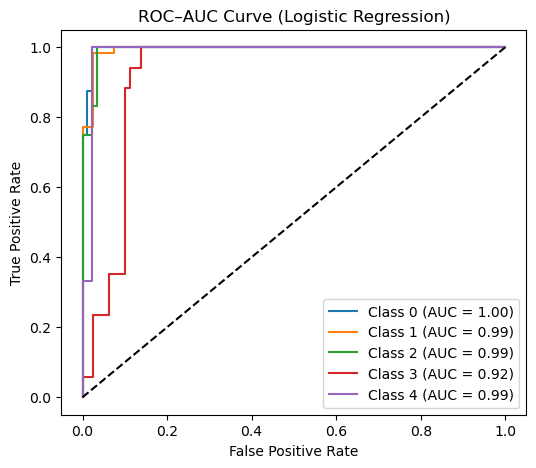

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Probabilities
y_prob_lr = lr.predict_proba(X_test)

plt.figure(figsize=(6,5))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve (Logistic Regression)")
plt.legend()
plt.show()


**K-FOLD ACCURACY**

In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

kfold_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    kfold_results.append([name, scores.mean()])

df_kfold = pd.DataFrame(
    kfold_results,
    columns=["Model", "K-Fold Accuracy"]
)

df_kfold


C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\AUSU\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

,Model,K-Fold Accuracy
0,Logistic Regression,0.678351
1,KNN,0.915464
2,Naive Bayes,0.913402
3,Decision Tree,0.993814
4,SVM,0.917526


**Accuracy Comparison Bar Graph**

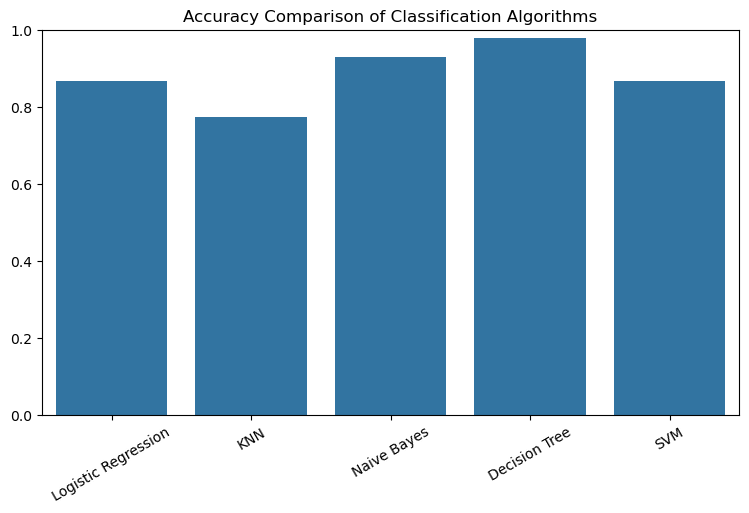

In [ ]:
models = ['Logistic Regression', 'KNN', 'Naive Bayes', 'Decision Tree', 'SVM']

accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_svm)
]

plt.figure(figsize=(9,5))
sns.barplot(x=models, y=accuracies)
plt.title("Accuracy Comparison of Classification Algorithms")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.show()


**AQI Category Distribution**

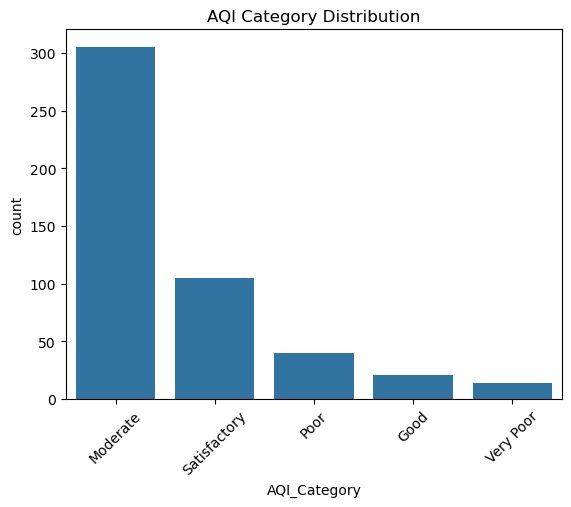

In [ ]:
sns.countplot(x=df_pivot['AQI_Category'])
plt.xticks(rotation=45)
plt.title("AQI Category Distribution")
plt.show()


**Correlation Heatmap**

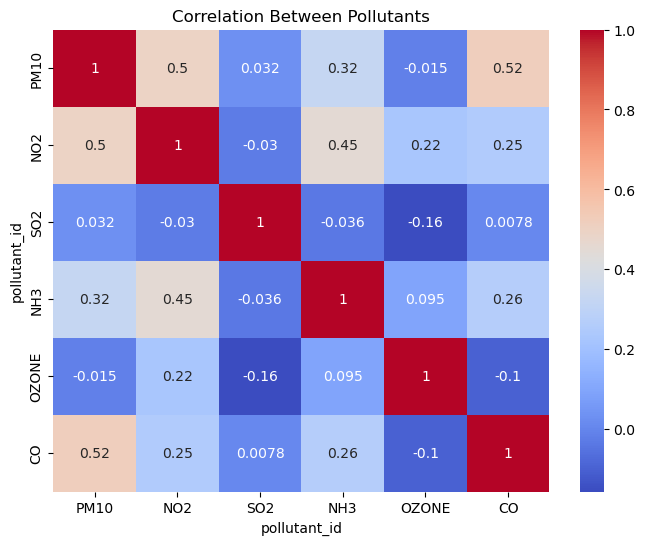

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_pivot[['PM10','NO2','SO2','NH3','OZONE','CO']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Between Pollutants")
plt.show()


**Confusion Matrix**

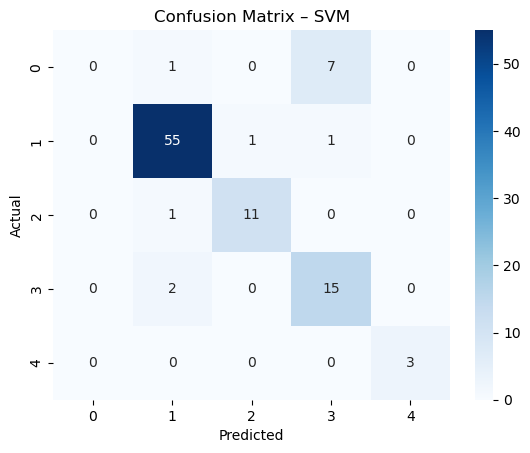

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


**Histogram (Pollutant Distribution)**

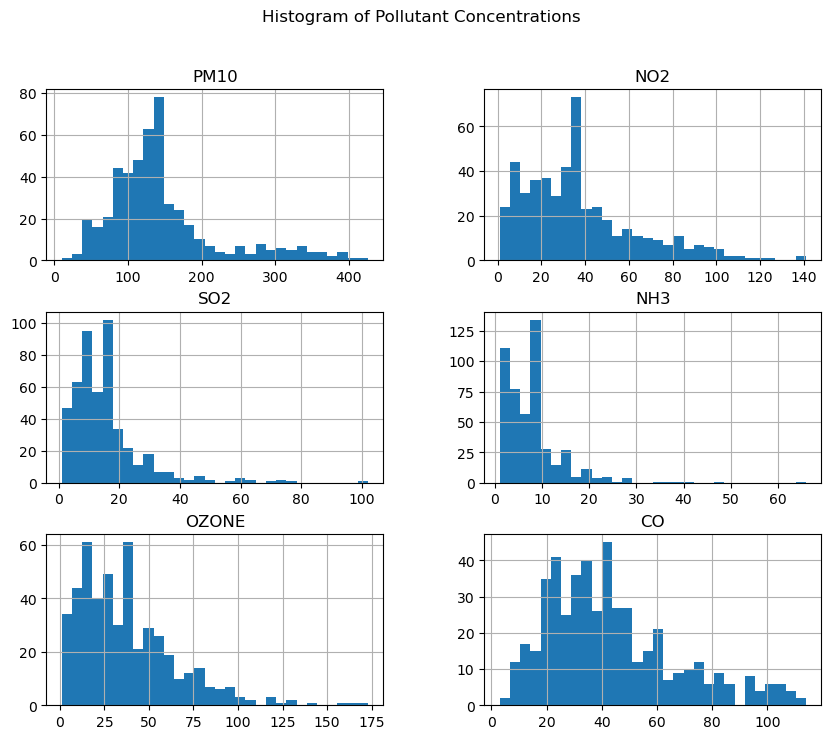

In [ ]:
df_pivot[['PM10','NO2','SO2','NH3','OZONE','CO']].hist(
    figsize=(10,8),
    bins=30
)
plt.suptitle("Histogram of Pollutant Concentrations")
plt.show()
